# Gráficos - Analise de Vendas
Matplotlib

In [42]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/marcosroquerosa/datasets/refs/heads/main/dados_tratados.csv")

# Datas
df["pedido_data"] = pd.to_datetime(df["pedido_data"])
df["ano"] = df["pedido_data"].dt.year
df["ano_mes"] = df["pedido_data"].dt.to_period("M").astype(str)

# Receita
df["receita"] = df["pedido_valor"] + df["pedido_frete"]

**Gráficos com Pandas**
- Atalho do Matplotlib
- rápido para exploração
- menos código
- ✖ pouco controle
✖ customização limitada
✖ estética fraca para apresentação

<Axes: title={'center': 'Receita ao longo do tempo'}, xlabel='ano_mes'>

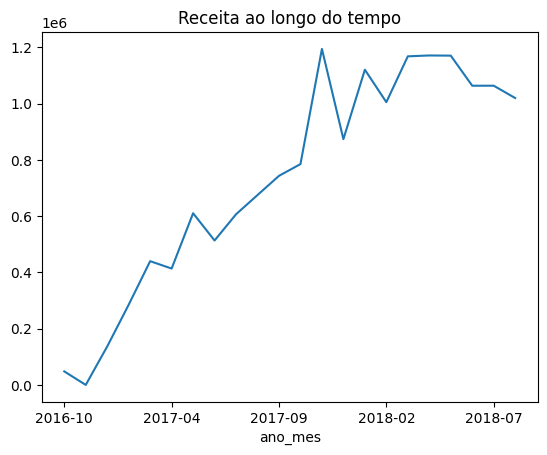

In [43]:
# Gráfico de Linha (line) ou área - Receita ao longo do tempo
df.groupby('ano_mes')['receita'].sum().plot(kind='line', title='Receita ao longo do tempo')
# df.groupby('ano_mes')['receita'].sum().plot(kind='area', title='Receita ao longo do tempo')

<Axes: title={'center': 'Receita vs Pedidos'}, xlabel='ano_mes'>

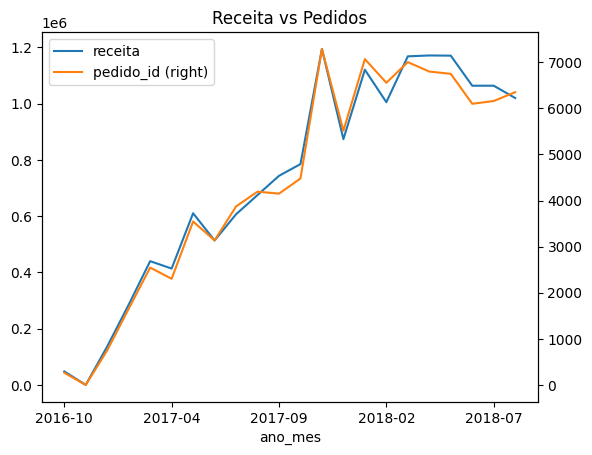

In [44]:
# Dois eixos - Receita vs Pedidos
df_agg = df.groupby('ano_mes').agg({
    'receita': 'sum',
    'pedido_id': 'nunique'
})
df_agg.plot(secondary_y='pedido_id', title='Receita vs Pedidos')

<Axes: title={'center': 'Top 10 Categorias'}, ylabel='produto_categoria'>

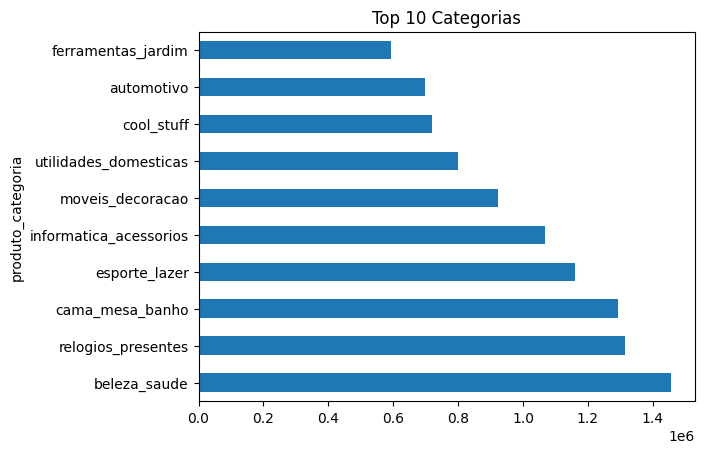

In [45]:
# Gráfico de Barras (bar) - Top 10 Categorias
df.groupby('produto_categoria')['receita'].sum() \
  .sort_values(ascending=False).head(10) \
  .plot(kind='barh', title='Top 10 Categorias') # bar (vertical) ou barh (horizontal)

<Axes: title={'center': 'Top 5 Estados por Receita'}, xlabel='cliente_uf'>

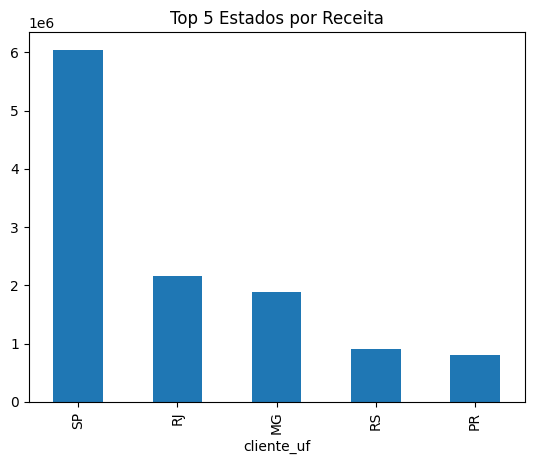

In [46]:
# Receita por Estado (Top 5)
df.groupby('cliente_uf')['receita'] \
  .sum().sort_values(ascending=False).head(5) \
  .plot(kind='bar', title='Top 5 Estados por Receita')

# Matplotlib

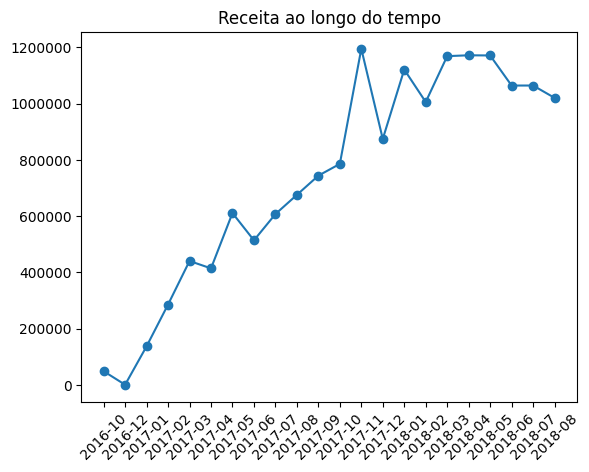

In [47]:
# Gráfico de Linha (evolução temporal)
import matplotlib.pyplot as plt

vendas_mes = df.groupby("ano_mes")["receita"].sum()

plt.plot(vendas_mes.index.astype(str), vendas_mes.values, marker='o')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') # Desativar notação científica
plt.title("Receita ao longo do tempo")
plt.show()

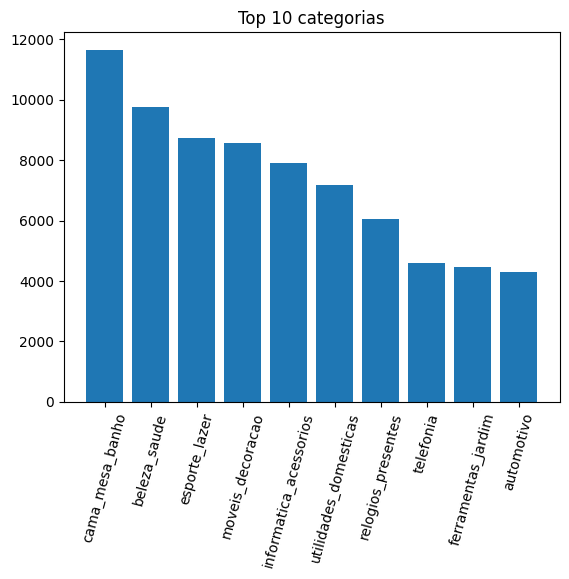

In [48]:
# Barras (categorias) - Top 10 categorias
top_categorias = df["produto_categoria"].value_counts().head(10)

plt.bar(top_categorias.index, top_categorias.values)
plt.xticks(rotation=75)
plt.title("Top 10 categorias")
plt.show()

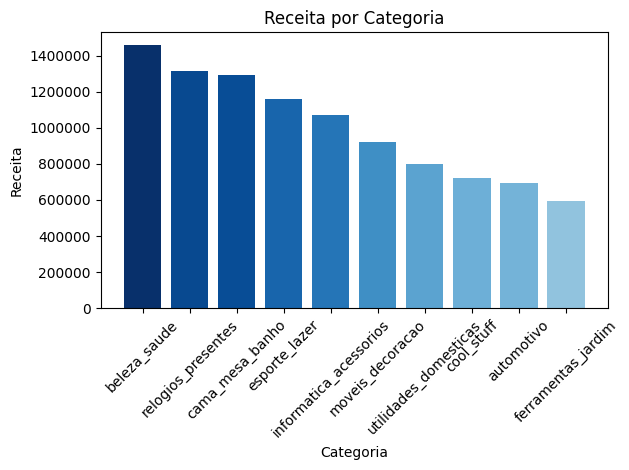

In [49]:
# Barras (categorias) - Top 10 categorias
receita_categoria = df.groupby('produto_categoria')['receita'].sum().sort_values(ascending=False).head(10)

# (1º teste) Cores - Maior azul e demais cinza
# cores = ['gray'] * len(receita_categoria)
# cores[0] = 'blue'  # maior categoria

# (2º teste) Cor baseada no valor - Azul
norm = receita_categoria / receita_categoria.max()
cores = plt.cm.Blues(norm)

plt.bar(receita_categoria.index, receita_categoria.values, color=cores)

plt.ticklabel_format(style='plain', axis='y') # Desativar notação científica

plt.title('Receita por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Receita')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

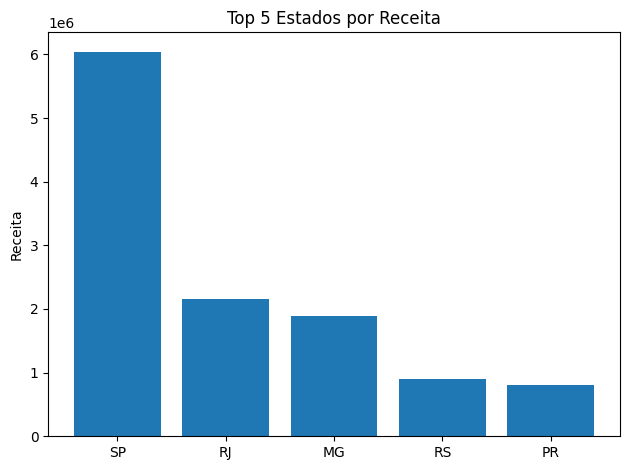

In [50]:
# Receita por Estado (Top 5)
uf = df.groupby('cliente_uf')['receita'] \
       .sum().sort_values(ascending=False).head(5)

plt.figure()
plt.bar(uf.index, uf.values)
plt.title('Top 5 Estados por Receita')
plt.ylabel('Receita')
plt.tight_layout()
plt.show()

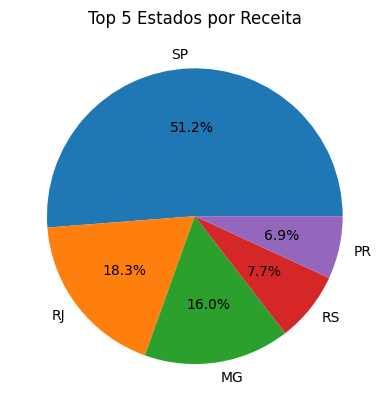

In [51]:
# Pizza Receita por Estado (Top 5)
estado = df.groupby("cliente_uf")["receita"].sum().nlargest(5)

plt.pie(estado.values, labels=estado.index, autopct='%1.1f%%')
plt.title("Top 5 Estados por Receita")
plt.show()